# Comparatif LLM locaux (Ollama)

Graphiques du challenge : lecture du bronze (`cerveau='ollama'`) via DuckDB.

**Explications** (protocole coach, inputs des IA, critères de progression) :
[README.md § Challenge LLM](README.md#challenge-llm-locaux-expérience--srcchallenge_llmpy) et
[NOTES.md §16](NOTES.md#16-challenge-llm-locaux-carte-défi).

```bash
uv run python src/challenge_llm.py --carte defi --iterations 5
# puis exécuter ce notebook
```


In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect()

runs = con.sql("""
    select * from read_parquet('data/bronze/runs/*.parquet', union_by_name=true)
    where cerveau = 'ollama'
""").df()

turns = con.sql("""
    select t.*, r.modele
    from read_parquet('data/bronze/turns/*.parquet', union_by_name=true) t
    join read_parquet('data/bronze/runs/*.parquet', union_by_name=true) r using (run_id)
    where r.cerveau = 'ollama'
""").df()

if "iteration" not in runs.columns:   # bronze antérieur au contrat v3
    runs["iteration"] = pd.NA
    runs["memoire"] = pd.NA

# Deux populations : parties batch (indépendantes, sans mémoire) et parties
# des séquences itératives (avec expérience injectée dans le prompt).
runs_batch = runs[runs["iteration"].isna()]
runs_iter = runs[runs["iteration"].notna()]

# Les sections « performance brute » utilisent le batch (témoin) quand il
# existe, pour ne pas mélanger parties avec et sans mémoire.
runs_ref = runs_batch if len(runs_batch) else runs
turns_ref = turns[turns["run_id"].isin(runs_ref["run_id"])]

modeles = sorted(runs["modele"].unique())
print(f"{len(runs)} runs ({len(runs_batch)} batch, {len(runs_iter)} itératifs) · "
      f"{len(turns)} tours · modèles : {modeles}")
runs[["modele", "typologie", "iteration", "memoire", "success", "ors_ramasses",
      "n_or_initial", "turns", "invalides", "latence_moyenne_ms"]]

39 runs (9 batch, 30 itératifs) · 931 tours · modèles : ['gemma2:2b', 'llama3.2:1b', 'qwen2.5:0.5b']


,modele,typologie,iteration,memoire,success,ors_ramasses,n_or_initial,turns,invalides,latence_moyenne_ms
0,gemma2:2b,initiale,<NA>,<NA>,False,1,3,30,0,3453
1,gemma2:2b,initiale,4,True,False,1,3,30,0,4552
2,qwen2.5:0.5b,defi,4,True,True,1,1,12,1,4431
3,llama3.2:1b,initiale,4,True,False,0,3,30,0,2318
4,llama3.2:1b,defi,3,True,True,1,1,7,0,10641
5,llama3.2:1b,initiale,2,True,False,0,3,30,0,2431
6,llama3.2:1b,initiale,<NA>,<NA>,False,0,3,30,0,2080
7,llama3.2:1b,initiale,3,True,False,0,3,30,0,1564
8,gemma2:2b,defi,4,True,True,1,1,9,0,20565
9,llama3.2:1b,defi,5,True,False,0,1,20,0,9383


### Attributs et inputs des IA

→ Voir [README § Interprétation](README.md#interprétation--attributs-inputs-et-critères-de-progression) et [NOTES §16](NOTES.md#16-challenge-llm-locaux-carte-défi).


### Progression intra-partie (moyenne des runs batch)

Or cumulé et distance à l'or — mesurés par l'arbitre. Lecture : [README § graphiques](README.md#interprétation--graphiques-du-notebook-comparatif_llmipynb).


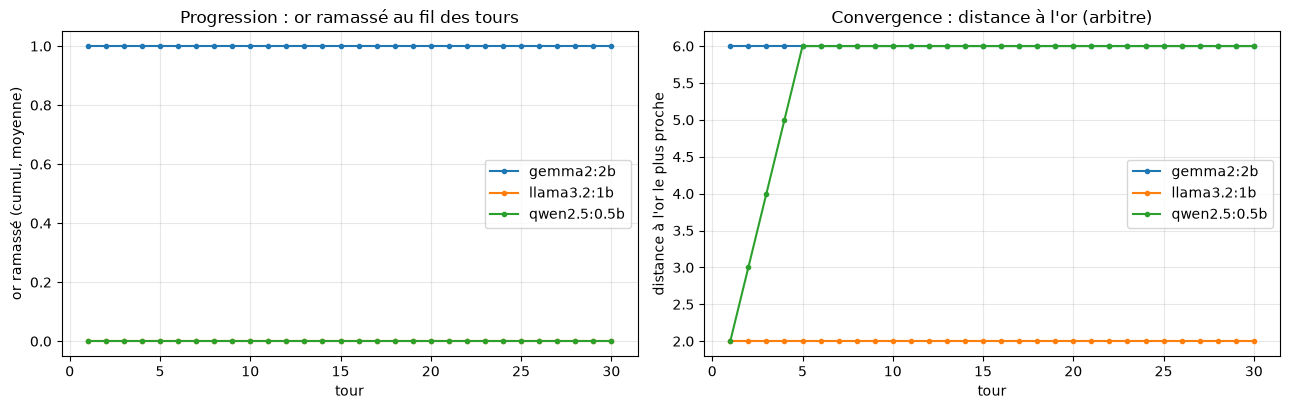

In [2]:
couleurs = {m: plt.cm.tab10.colors[i % 10] for i, m in enumerate(modeles)}

# Or ramassé cumulé par tour (n_or_initial - ors_restants), moyenne par modèle.
turns_ref = turns_ref.copy()
turns_ref["or_cumule"] = turns_ref.merge(
    runs_ref[["run_id", "n_or_initial"]], on="run_id"
)["n_or_initial"].values - turns_ref["ors_restants"].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

for m in modeles:
    sous = turns_ref[turns_ref["modele"] == m]
    prog = sous.groupby("tour")["or_cumule"].mean()
    ax1.plot(prog.index, prog.values, marker="o", markersize=3,
             label=m, color=couleurs[m])
    dist = sous.groupby("tour")["distance_or"].mean()
    ax2.plot(dist.index, dist.values, marker="o", markersize=3,
             label=m, color=couleurs[m])

ax1.set_xlabel("tour"); ax1.set_ylabel("or ramassé (cumul, moyenne)")
ax1.set_title("Progression : or ramassé au fil des tours")
ax1.grid(alpha=0.3); ax1.legend()

ax2.set_xlabel("tour"); ax2.set_ylabel("distance à l'or le plus proche")
ax2.set_title("Convergence : distance à l'or (arbitre)")
ax2.grid(alpha=0.3); ax2.legend()

fig.tight_layout()
plt.show()

### Barres comparatives (runs batch)

Part d'or ramassé, tours moyens, latence par modèle.


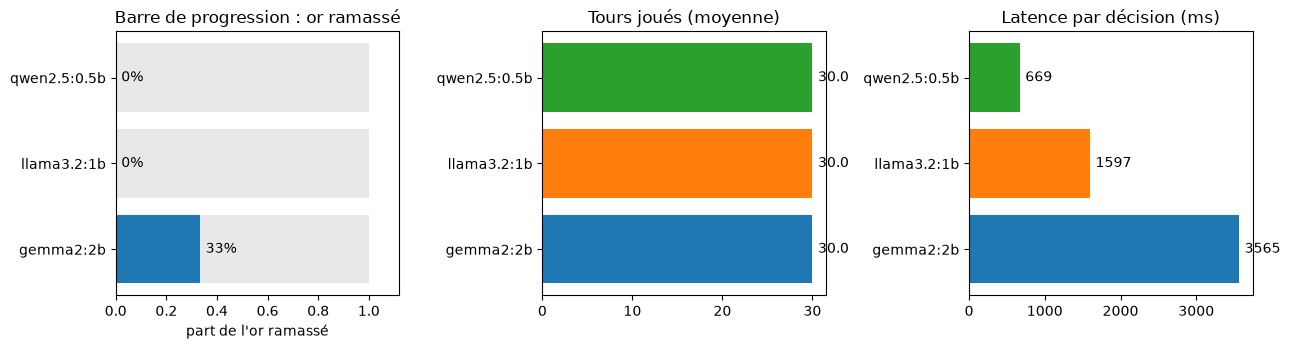

In [3]:
agg = runs_ref.groupby("modele").agg(
    taux_or=("ors_ramasses", lambda s: s.sum() / runs_ref.loc[s.index, "n_or_initial"].sum()),
    taux_reussite=("success", "mean"),
    tours_moyens=("turns", "mean"),
    latence_ms=("latence_moyenne_ms", "mean"),
    invalides=("invalides", "mean"),
    n_runs=("run_id", "count"),
).reindex(modeles)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# Barre de progression : % d'or ramassé, fond gris = 100 %.
axes[0].barh(agg.index, [1.0] * len(agg), color="#e8e8e8")
b = axes[0].barh(agg.index, agg["taux_or"],
                 color=[couleurs[m] for m in agg.index])
axes[0].bar_label(b, labels=[f"{v:.0%}" for v in agg["taux_or"]], padding=4)
axes[0].set_xlim(0, 1.12)
axes[0].set_title("Barre de progression : or ramassé")
axes[0].set_xlabel("part de l'or ramassé")

b = axes[1].barh(agg.index, agg["tours_moyens"],
                 color=[couleurs[m] for m in agg.index])
axes[1].bar_label(b, fmt="%.1f", padding=4)
axes[1].set_title("Tours joués (moyenne)")

b = axes[2].barh(agg.index, agg["latence_ms"],
                 color=[couleurs[m] for m in agg.index])
axes[2].bar_label(b, fmt="%.0f", padding=4)
axes[2].set_title("Latence par décision (ms)")

fig.tight_layout()
plt.show()

### Tableau comparatif (runs batch)

Classement par or ramassé, tours et invalides JSON.


In [4]:
classement = agg.sort_values(["taux_or", "tours_moyens"],
                             ascending=[False, True]).round(3)
classement.insert(0, "rang", range(1, len(classement) + 1))
classement

,rang,taux_or,taux_reussite,tours_moyens,latence_ms,invalides,n_runs
modele,,,,,,,
gemma2:2b,1,0.333,0.0,30.0,3565.333,0.0,3
llama3.2:1b,2,0.000,0.0,30.0,1596.667,0.0,3
qwen2.5:0.5b,3,0.000,0.0,30.0,669.333,0.0,3


### Progression inter-parties (carte `defi`, mémoire)

Une courbe par typologie itérative en bronze. Chaque nouvelle partie ajoute un point.
→ Protocole coach : [NOTES §16](NOTES.md#protocole-coach-à-aide-graduée).


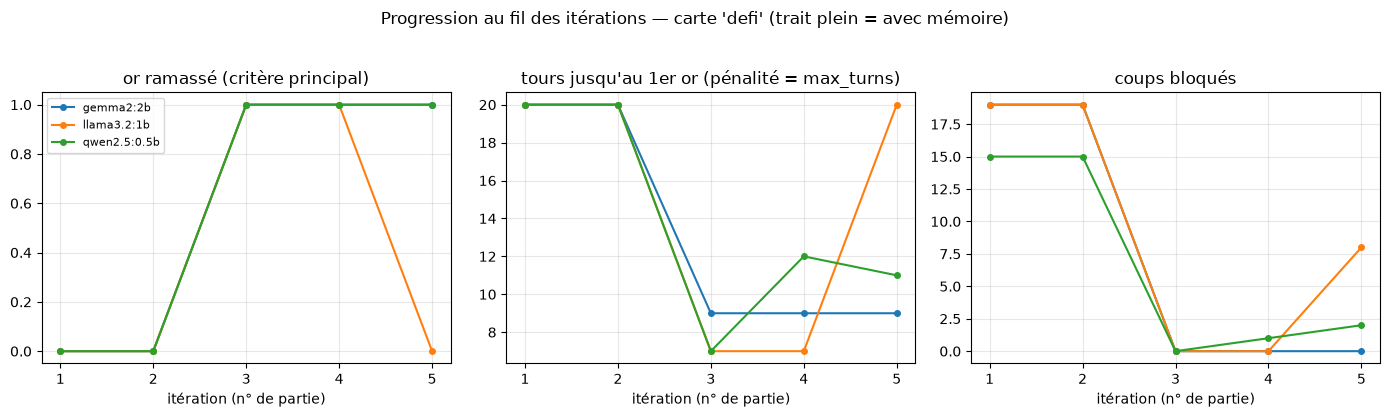

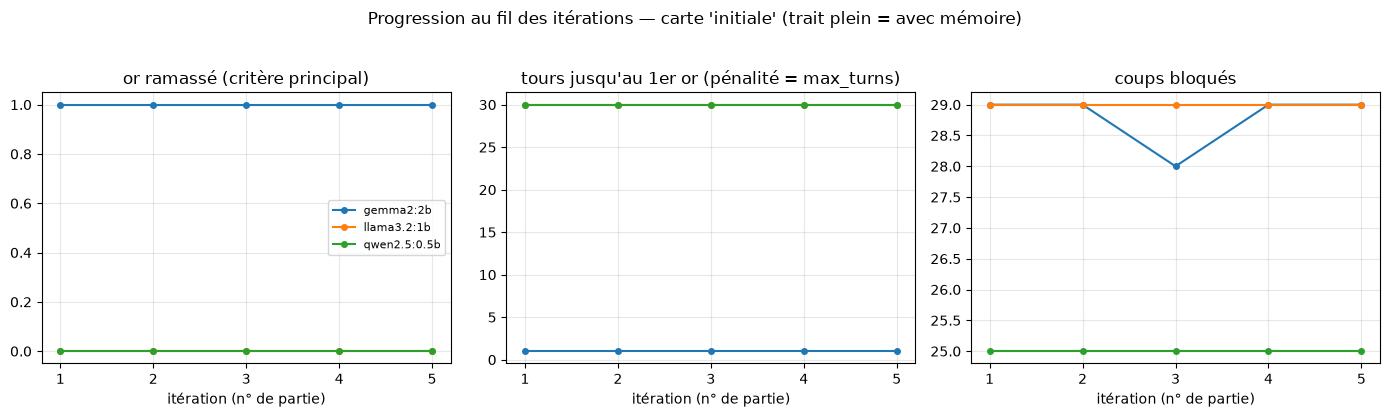

In [5]:
if runs_iter.empty:
    print("Aucune séquence itérative en bronze : lancer "
          "`uv run python src/challenge_llm.py --iterations 5` puis ré-exécuter.")
else:
    for typo in sorted(runs_iter["typologie"].unique()):
        it = runs_iter[runs_iter["typologie"] == typo].copy()
        it["iteration"] = it["iteration"].astype(int)

        # Tours jusqu'au 1er or (NaN si aucun or ramassé -> pénalité max_turns).
        premier_or = (
            turns[turns["or_ramasse"]]
            .groupby("run_id")["tour"].min().rename("tour_premier_or")
        )
        it = it.merge(premier_or, on="run_id", how="left")
        it["tour_premier_or"] = it["tour_premier_or"].fillna(it["max_turns"])

        # Coups bloqués par partie (le pion n'a pas bougé).
        bloques = (
            turns[turns["run_id"].isin(it["run_id"])]
            .assign(bloque=lambda d: ~d["bouge"])
            .groupby("run_id")["bloque"].sum().rename("coups_bloques")
        )
        it = it.merge(bloques, on="run_id", how="left")

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        criteres = [
            ("ors_ramasses", "or ramassé (critère principal)", axes[0]),
            ("tour_premier_or", "tours jusqu'au 1er or (pénalité = max_turns)", axes[1]),
            ("coups_bloques", "coups bloqués", axes[2]),
        ]
        for col, titre, ax in criteres:
            for m in sorted(it["modele"].unique()):
                for memo, style in [(True, "-o"), (False, "--s")]:
                    sous = it[(it["modele"] == m) & (it["memoire"] == memo)]
                    if sous.empty:
                        continue
                    serie = sous.groupby("iteration")[col].mean()
                    suffixe = "" if memo else " (sans mémoire)"
                    ax.plot(serie.index, serie.values, style, markersize=4,
                            color=couleurs.get(m), alpha=1.0 if memo else 0.45,
                            label=f"{m}{suffixe}")
            ax.set_xlabel("itération (n° de partie)")
            ax.set_title(titre)
            ax.grid(alpha=0.3)
            ax.xaxis.get_major_locator().set_params(integer=True)
        axes[0].legend(fontsize=8)
        fig.suptitle(f"Progression au fil des itérations — carte '{typo}' "
                     "(trait plein = avec mémoire)", y=1.03)
        fig.tight_layout()
        plt.show()

### Trajectoires sur la carte `defi`

Couleur = n° d'itération (clair → foncé). Or = jaune, ennemis = rouge, départ = vert.


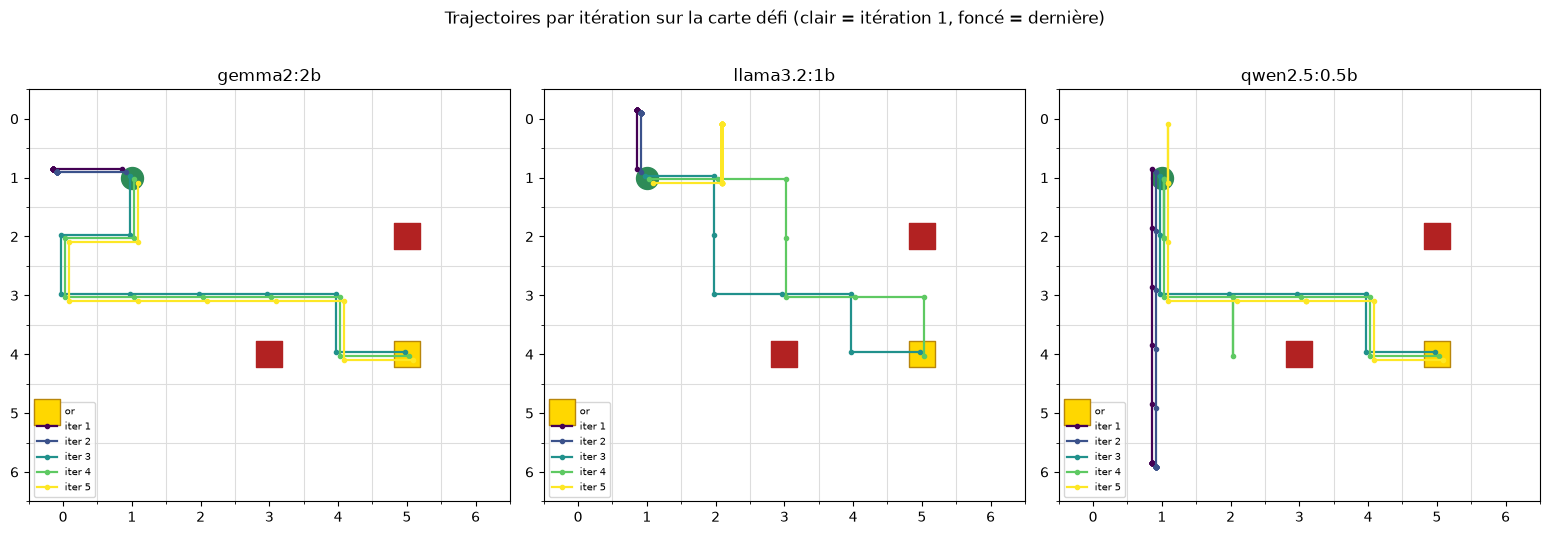

In [6]:
import numpy as np

# Carte défi telle que définie dans npc_brain.ipynb (0=vide, 1=J, 2=E, 3=or).
CARTE_DEFI = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 2, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 2, 0, 3, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
])

runs_defi = runs_iter[runs_iter["typologie"] == "defi"]
if runs_defi.empty:
    print("Aucun run itératif sur la carte 'defi' : lancer "
          "`uv run python src/challenge_llm.py --carte defi --iterations 5`.")
else:
    modeles_defi = sorted(runs_defi["modele"].unique())
    fig, axes = plt.subplots(1, len(modeles_defi),
                             figsize=(5.2 * len(modeles_defi), 5.2))
    if len(modeles_defi) == 1:
        axes = [axes]

    for ax, m in zip(axes, modeles_defi):
        # Fond : grille + entités fixes.
        n = CARTE_DEFI.shape[0]
        ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
        ax.grid(which="minor", color="#dddddd", linewidth=0.8)
        ax.set_xlim(-0.5, n - 0.5); ax.set_ylim(n - 0.5, -0.5)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        for (r, c) in zip(*np.where(CARTE_DEFI == 3)):
            ax.scatter(c, r, marker="s", s=350, color="gold",
                       edgecolors="darkgoldenrod", zorder=2, label="or")
        for (r, c) in zip(*np.where(CARTE_DEFI == 2)):
            ax.scatter(c, r, marker="s", s=350, color="firebrick", zorder=2)
        for (r, c) in zip(*np.where(CARTE_DEFI == 1)):
            ax.scatter(c, r, marker="o", s=250, color="seagreen", zorder=2)

        # Trajectoires : une couleur par itération, du clair au foncé.
        sous_runs = runs_defi[runs_defi["modele"] == m].sort_values("iteration")
        n_iter = len(sous_runs)
        cmap = plt.get_cmap("viridis", max(n_iter, 2))
        for k, (_, run_row) in enumerate(sous_runs.iterrows()):
            traj = turns[turns["run_id"] == run_row["run_id"]].sort_values("tour")
            xs = [traj.iloc[0]["pos_avant_col"]] + traj["pos_apres_col"].tolist()
            ys = [traj.iloc[0]["pos_avant_row"]] + traj["pos_apres_row"].tolist()
            # léger décalage pour distinguer les itérations superposées
            jit = (k - n_iter / 2) * 0.06
            ax.plot(np.array(xs) + jit, np.array(ys) + jit, "-o",
                    markersize=3, linewidth=1.6, color=cmap(k), zorder=3,
                    label=f"iter {int(run_row['iteration'])}")
        ax.set_title(m)
        ax.legend(fontsize=7, loc="lower left")

    fig.suptitle("Trajectoires par itération sur la carte défi "
                 "(clair = itération 1, foncé = dernière)", y=1.02)
    fig.tight_layout()
    plt.show()

### Raisonnements déclarés (contrat v4)

Tours clés de la dernière itération : confronter `raison` (dite) et `effet` (réel).
→ [NOTES § traçage](NOTES.md#traçage-mouvements-et-raisonnements-contrat-v4).


In [7]:
if runs_defi.empty or "raison" not in turns.columns:
    print("Pas de raisons loggées (runs antérieurs au contrat v4 ou pas de runs defi).")
else:
    extraits = []
    for m in modeles_defi:
        sous_runs = runs_defi[runs_defi["modele"] == m].sort_values("iteration")
        derniere = sous_runs.iloc[-1]
        traj = turns[turns["run_id"] == derniere["run_id"]].sort_values("tour")
        prev_dir = None
        for _, t in traj.iterrows():
            cle = (
                t["tour"] == 1 or t["or_ramasse"]
                or t["direction"] != prev_dir or not t["bouge"]
            )
            if cle and pd.notna(t.get("raison")):
                evenement = ("OR RAMASSÉ" if t["or_ramasse"]
                             else "bloqué" if not t["bouge"] else "avance")
                extraits.append({
                    "modele": m,
                    "iteration": int(derniere["iteration"]),
                    "tour": int(t["tour"]),
                    "position": f"({int(t['pos_avant_row'])},{int(t['pos_avant_col'])})",
                    "direction": t["direction"],
                    "effet": evenement,
                    "raison (déclarée par le modèle)": t["raison"],
                })
            prev_dir = t["direction"]

    table_raisons = pd.DataFrame(extraits)
    pd.set_option("display.max_colwidth", 100)
    display(table_raisons.groupby("modele").head(8).reset_index(drop=True))

,modele,iteration,tour,position,direction,effet,raison (déclarée par le modèle)
0,gemma2:2b,5,1,"(1,1)",BAS,avance,"La direction gagnante est toujours BAS, car c'est la direction qui a permis de gagner la partie ..."
1,gemma2:2b,5,2,"(2,1)",GAUCHE,avance,"La direction gagnante de la partie précédente est GAUCHE, et cette direction doit être utilisée ..."
2,gemma2:2b,5,3,"(2,0)",BAS,avance,"La direction gagnante de la partie précédente est BAS, et il faut suivre cette direction pour co..."
3,gemma2:2b,5,4,"(3,0)",DROITE,avance,"La direction gagnante de la partie précédente est DROITE, et il faut suivre cette direction pour..."
4,gemma2:2b,5,8,"(3,4)",BAS,avance,"La direction gagnante est toujours BAS, car c'est la direction qui a permis de gagner la partie ..."
5,gemma2:2b,5,9,"(4,4)",DROITE,OR RAMASSÉ,"La direction gagnante est DROITE, car c'est la direction qui a permis de gagner la partie précéd..."
6,llama3.2:1b,5,1,"(1,1)",DROITE,avance,"Puisque J est sur la ligne haute, il faut jouer DROITE pour éviter de se coincer contre les bord..."
7,llama3.2:1b,5,2,"(1,2)",HAUT,avance,"La grille est limitée et il n'y a pas de $ à récupérer, donc la meilleure direction pour J est D..."
8,llama3.2:1b,5,3,"(0,2)",HAUT,bloqué,"La ligne est plus longue que la colonne, donc pour atteindre J, il faut augmenter la colonne."
9,llama3.2:1b,5,4,"(0,2)",HAUT,bloqué,"La ligne est plus longue que la colonne, donc pour ramasser les $, il faut aller au bas de la gr..."


### Synthèse

Interprétation détaillée des courbes et des résultats observés :
[NOTES §16 — Résultats observés](NOTES.md#résultats-observés-carte-defi-3-modèles--5-itérations).
